<a href="https://colab.research.google.com/github/HoangHumg1210/hoankiem-air-quality-forecasting/blob/main/notebooks/06_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
# df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
# df = pd.read_csv("data/processed/data2225_done.csv")


df = pd.read_csv('/content/data2225_done.csv')
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95.0,15.5,0.6,2.00,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94.0,15.4,0.7,2.33,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93.0,15.3,1.0,2.66,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93.0,15.2,1.5,3.00,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87.0,15.6,1.9,3.00,False,0


In [3]:

df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

In [ ]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_3"] = df["PM25"].shift(3)
df["PM25_lag_24"] = df["PM25"].shift(24)

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_3", "PM25_lag_24",
    "hour", "dayofweek", "month"
]].head())

                      PM25  PM25_lag_1  PM25_lag_3  PM25_lag_24  \
Local Time                                                        
2022-01-14 07:00:00  24.75       27.31       32.42        17.08   
2022-01-14 08:00:00  22.36       24.75       29.87        16.75   
2022-01-14 09:00:00  19.97       22.36       27.31        16.42   
2022-01-14 10:00:00  17.57       19.97       24.75        16.09   
2022-01-14 11:00:00  16.01       17.57       22.36        16.17   

                     PM25_roll_mean_3  PM25_roll_mean_6  PM25_roll_mean_24  \
Local Time                                                                   
2022-01-14 07:00:00         29.866667         31.063333          22.317500   
2022-01-14 08:00:00         27.310000         29.825000          22.637083   
2022-01-14 09:00:00         24.806667         28.175000          22.870833   
2022-01-14 10:00:00         22.360000         26.113333          23.018750   
2022-01-14 11:00:00         19.966667         23.638333       

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

print(skew_df)

                               skew         mean       median         min  \
Precipitation              6.435974     0.308527     0.000000    0.000000   
Accumulated Hours of Rain  5.659202     1.286397     0.000000    0.000000   
NO2                        4.910769    18.335192    11.000000    0.000000   
PM10                       4.818031    42.725697    30.330000    0.480000   
CO                         4.341903   523.411147   195.500000    0.000000   
SO2                        4.250056    36.284525    29.820000    0.000000   
PM25_lag_24                2.693140    21.112296    16.500000    0.480000   
PM25_lag_3                 2.687197    21.134762    16.500000    0.480000   
PM25_lag_1                 2.686935    21.135364    16.500000    0.480000   
PM25                       2.686771    21.135764    16.500000    0.480000   
PM25_roll_std_24           2.637767     7.661738     5.576020    0.292356   
PM25_roll_mean_3           2.528159    21.135076    16.750000    0.480000   

In [6]:
skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median       min  \
Precipitation              6.435974    0.308527    0.000000  0.000000   
Accumulated Hours of Rain  5.659202    1.286397    0.000000  0.000000   
NO2                        4.910769   18.335192   11.000000  0.000000   
PM10                       4.818031   42.725697   30.330000  0.480000   
CO                         4.341903  523.411147  195.500000  0.000000   
SO2                        4.250056   36.284525   29.820000  0.000000   
PM25_lag_24                2.693140   21.112296   16.500000  0.480000   
PM25_lag_3                 2.687197   21.134762   16.500000  0.480000   
PM25_lag_1                 2.686935   21.135364   16.500000  0.480000   
PM25                       2.686771   21.135764   16.500000  0.480000   
PM25_roll_std_24           2.637767    7.661738    5.576020  0.292356   
PM25_roll_mean_3           2.528159   21.135076   16.750000  0.480000   
PM25_roll_mean_6           2.

count    34735.000000
mean        21.135764
std         17.547543
min          0.480000
25%          9.900000
50%         16.500000
75%         26.000000
max        190.000000
Name: PM25, dtype: float64
Quantiles: {0.5: 16.5, 0.75: 26.0, 0.9: 40.5, 0.95: 54.6, 0.99: 91.2}


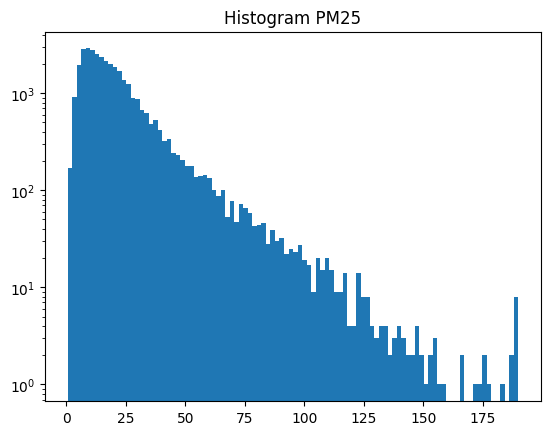

In [7]:
y = df['PM25'].dropna()
print(y.describe())
print("Quantiles:", y.quantile([0.5,0.75,0.9,0.95,0.99]).to_dict())

import matplotlib.pyplot as plt
plt.hist(y, bins=100)
plt.yscale('log')   # optional: log scale để nhìn đỉnh hiếm
plt.title("Histogram PM25")
plt.show()

In [8]:
th = y.quantile(0.90)
print("90% quantile:", th)
print("Percent above 90% quantile:", (y > th).mean())

90% quantile: 40.5
Percent above 90% quantile: 0.09961134302576652


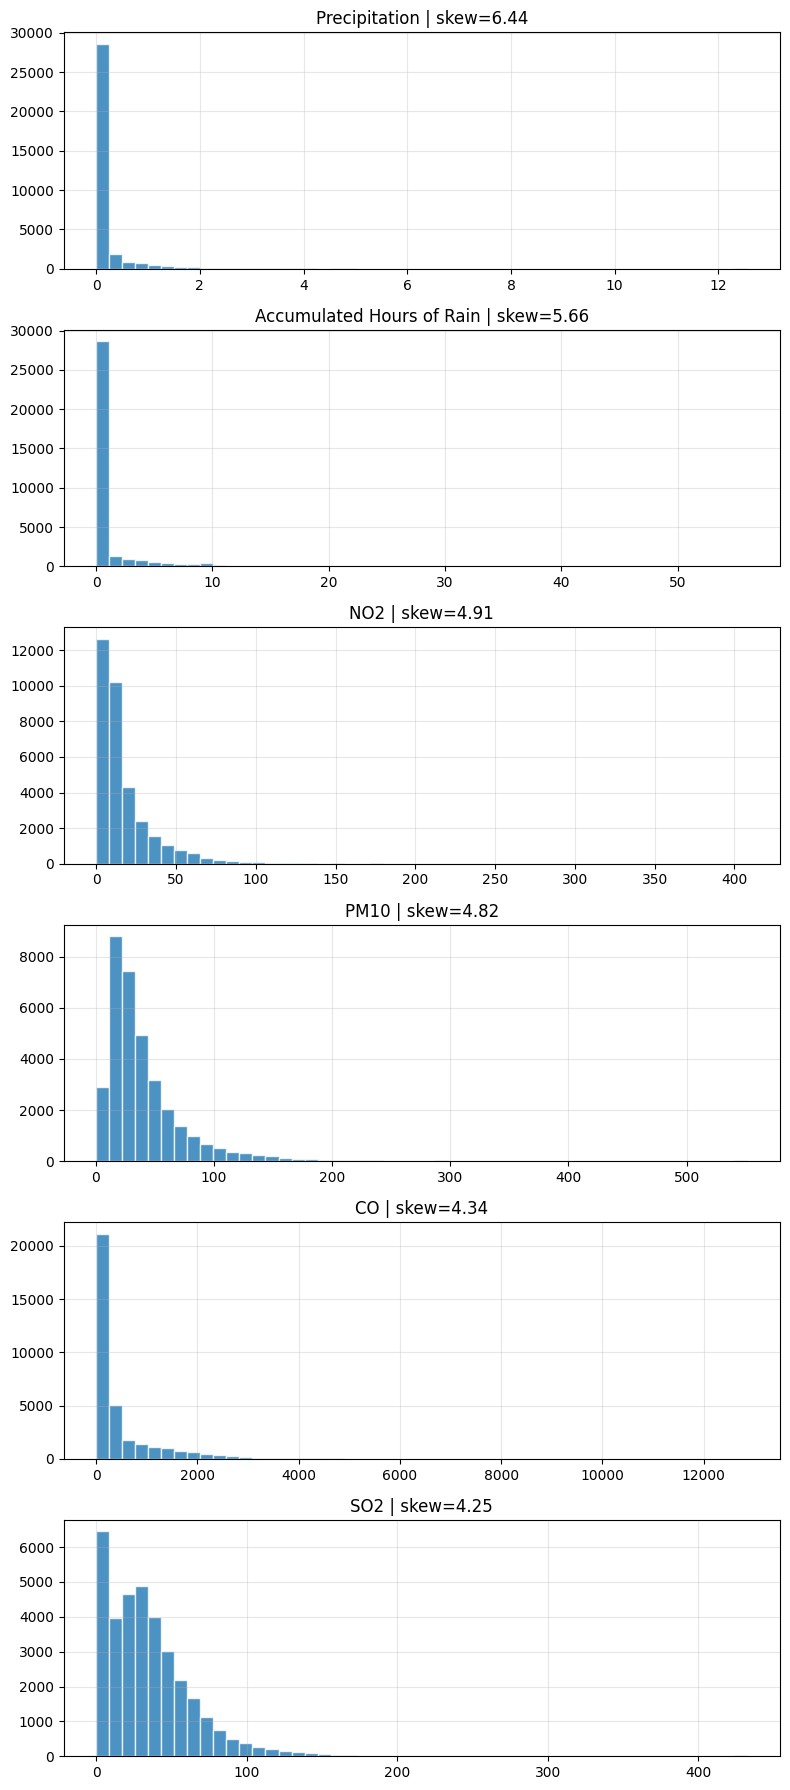

In [9]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
(df["PM25"] < 0).sum(), df.loc[df["PM25"] < 0, "PM25"].describe()

(np.int64(0),
 count    0.0
 mean     NaN
 std      NaN
 min      NaN
 25%      NaN
 50%      NaN
 75%      NaN
 max      NaN
 Name: PM25, dtype: float64)

In [11]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo tỷ lệ 70/15/15, giữ nguyên thứ tự thời gian =====
n_total = len(df)
train_size = int(n_total * 0.70)
val_size = int(n_total * 0.15)
test_size = n_total - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

train_end = train_df.index.max()
val_start = val_df.index.min()
val_end = val_df.index.max()
test_start = test_df.index.min()

print("Kích thước train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("Moc thoi gian:")
print("train:", train_df.index.min(), "->", train_end)
print("val  :", val_start, "->", val_end)
print("test :", test_start, "->", test_df.index.max())

Kích thước train/val/test: (24314, 25) (5210, 25) (5211, 25)
Moc thoi gian:
train: 2022-01-14 07:00:00 -> 2024-10-23 06:00:00
val  : 2024-10-23 07:00:00 -> 2025-05-28 16:00:00
test : 2025-05-28 17:00:00 -> 2025-12-31 23:00:00


In [12]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

train_log = np.log1p(train_df["PM25"])
val_log = np.log1p(val_df["PM25"])
test_log = np.log1p(test_df["PM25"])

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

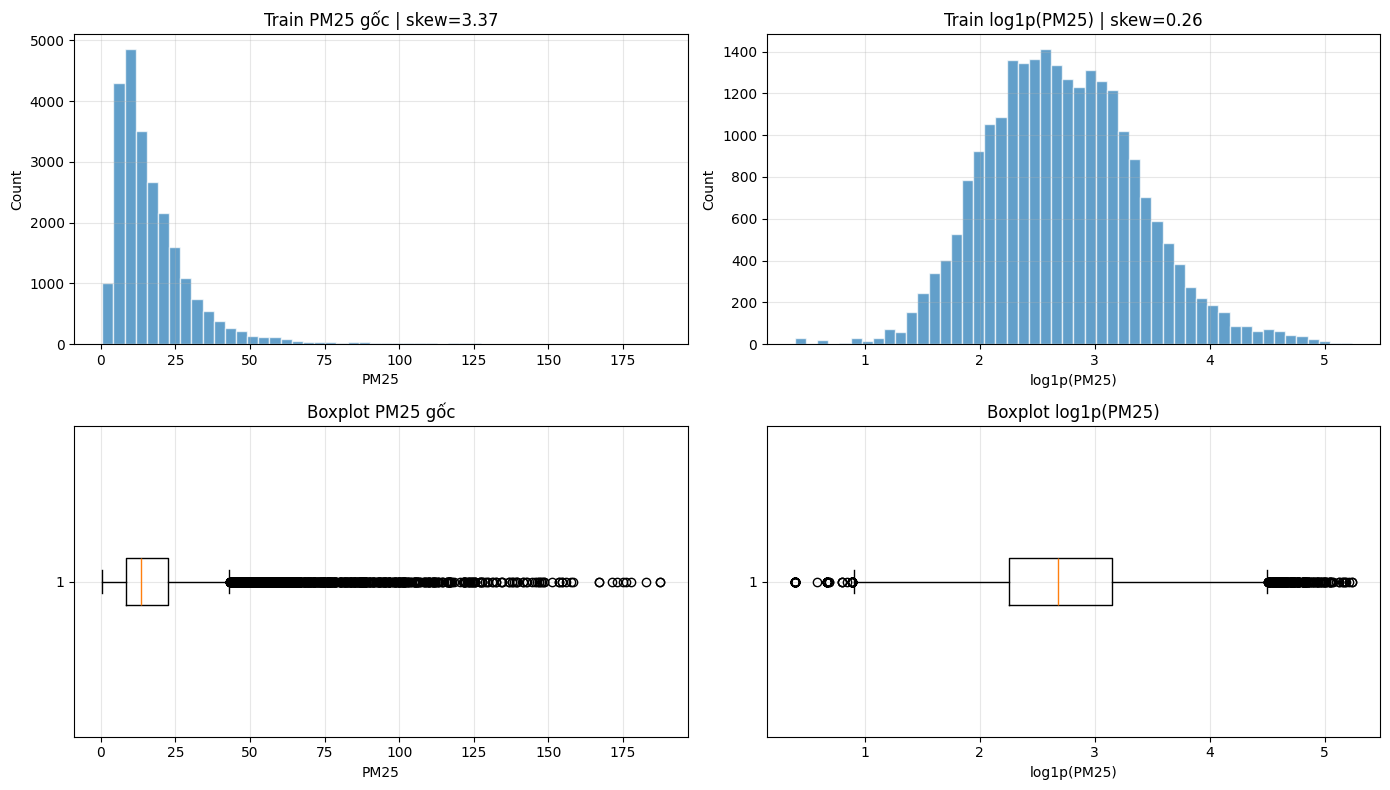

Độ lệch (skew) của dữ liệu gốc: 3.366529366942121
Độ lệch (skew) sau log: 0.26285986517320725


In [13]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Độ lệch (skew) của dữ liệu gốc:", pd.Series(y_train_raw_1d).skew())
print("Độ lệch (skew) sau log:", pd.Series(y_train_t_1d).skew())

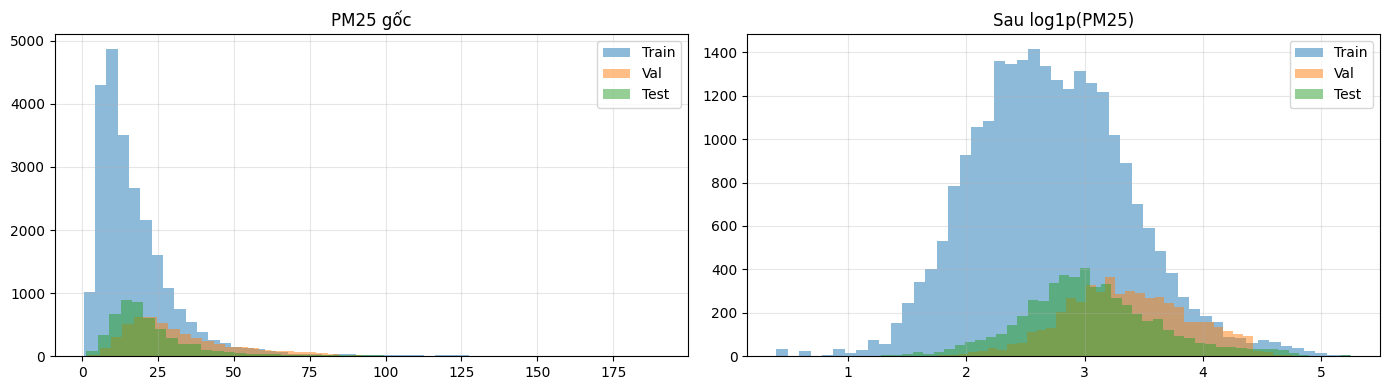

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

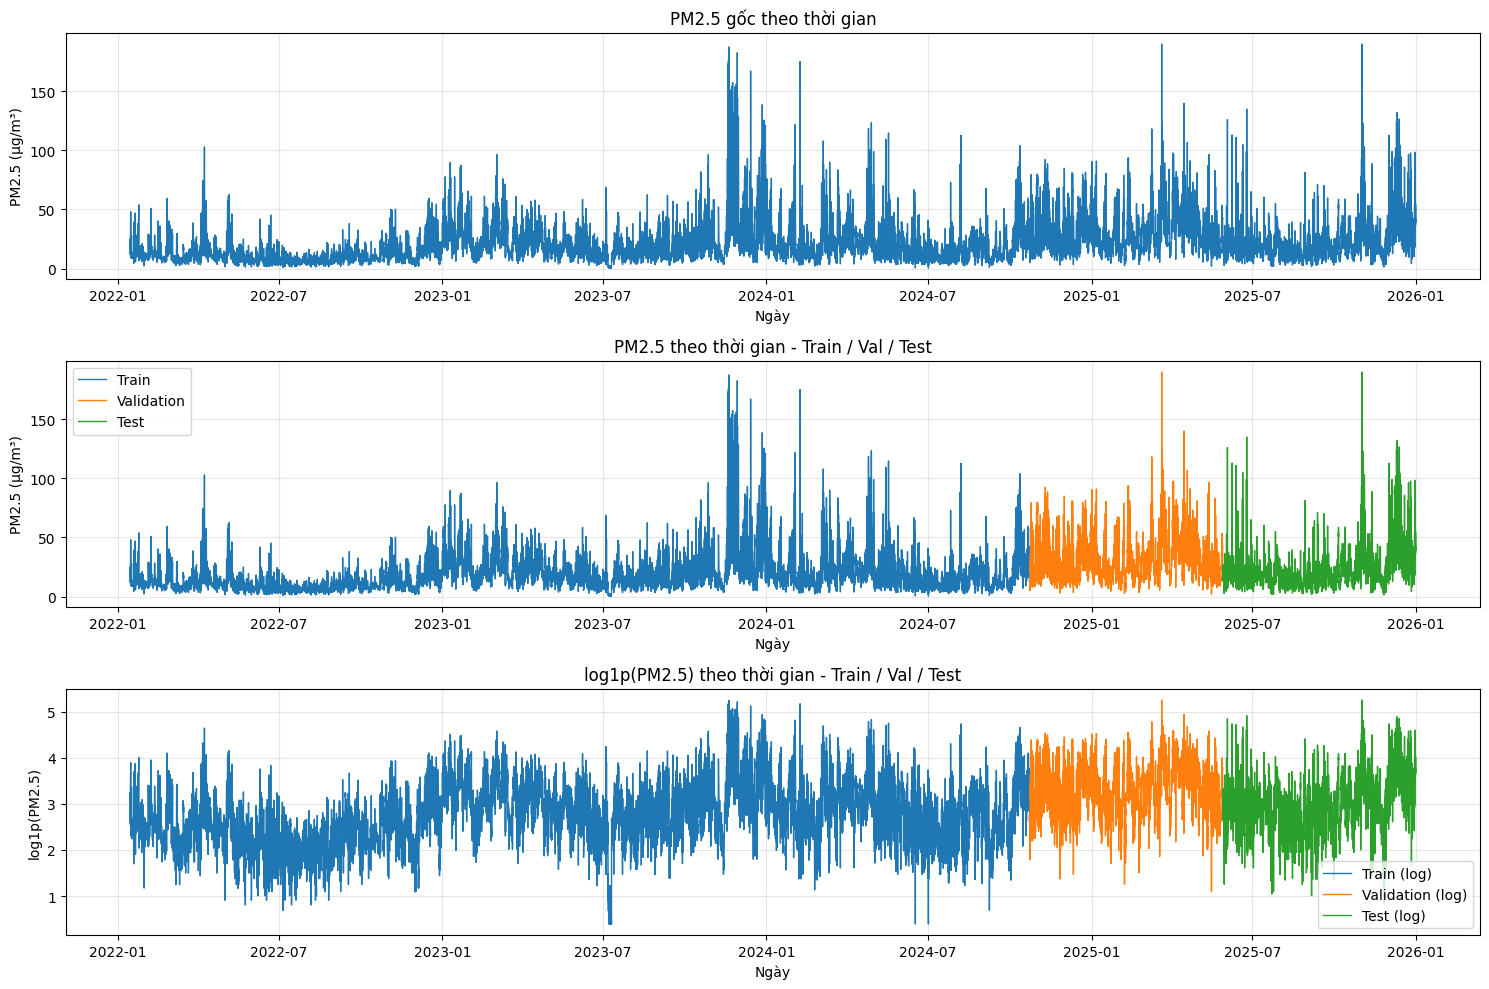

In [15]:


# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

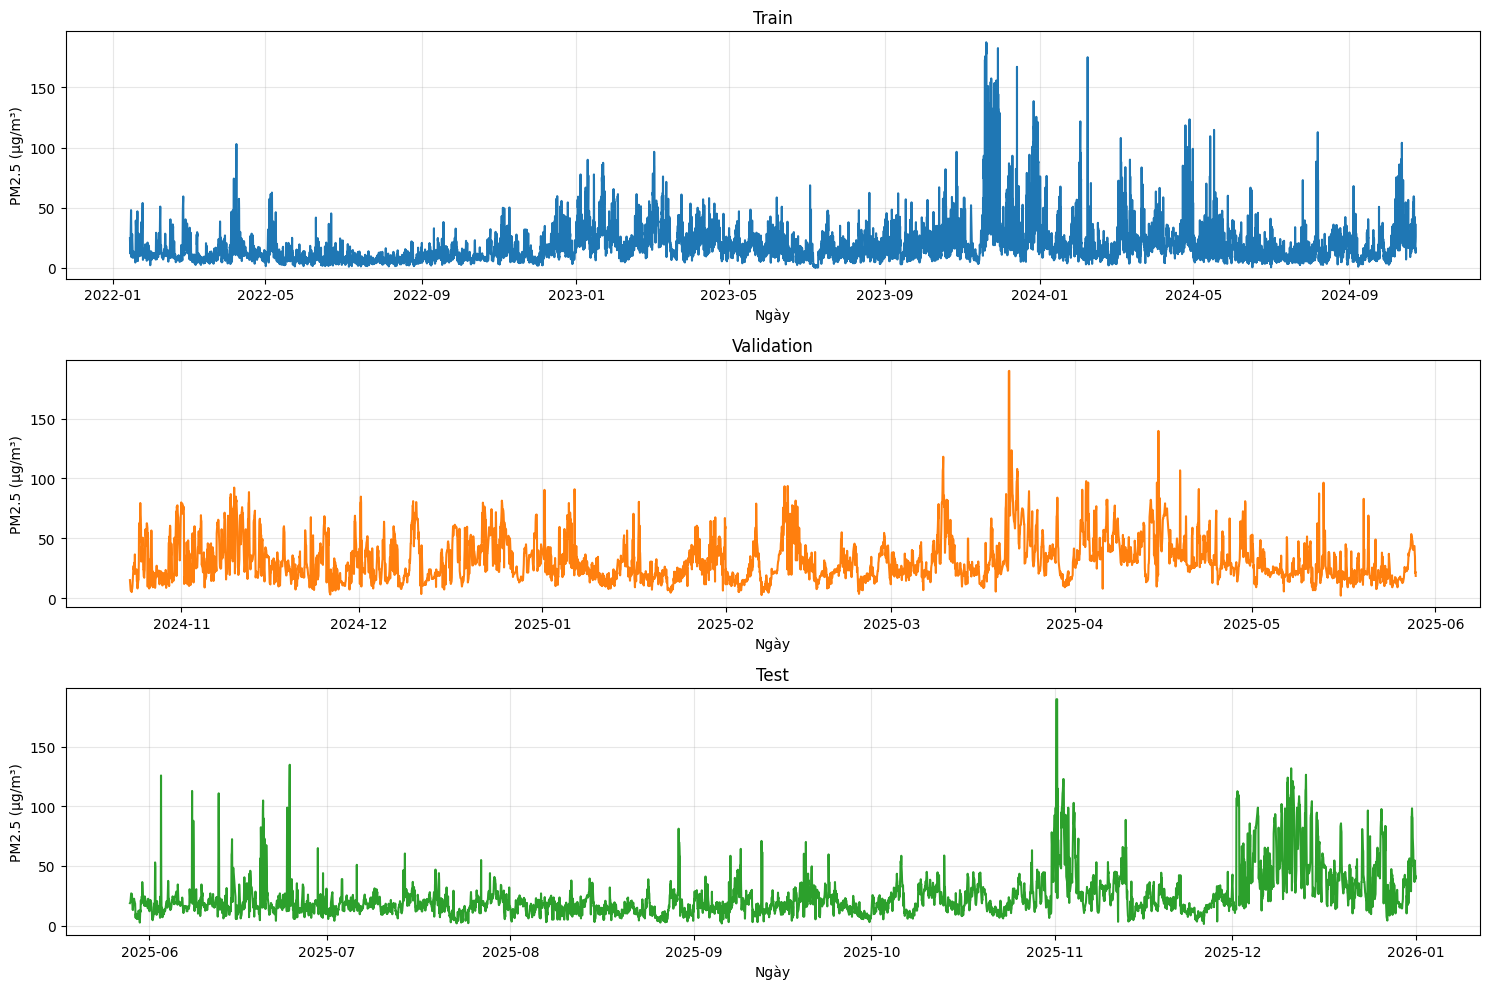

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

axes[0].plot(train_df.index, train_df["PM25"], label="Train")
axes[0].set_title("Train")
axes[0].grid(alpha=0.3)

axes[1].plot(val_df.index, val_df["PM25"], label="Validation", color='C1')
axes[1].set_title("Validation")
axes[1].grid(alpha=0.3)

axes[2].plot(test_df.index, test_df["PM25"], label="Test", color='C2')
axes[2].set_title("Test")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_xlabel("Ngày")

plt.tight_layout()
plt.show()

In [17]:
df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

for lag in [1, 3, 24, 72, 168]:
    df[f"PM25_lag_{lag}"] = df["PM25"].shift(lag)

shifted = df["PM25"].shift(1)

df["PM25_diff_1"] = shifted.diff(1)
df["PM25_diff_24"] = shifted.diff(24)

df = df.dropna().copy()

base_features = [
    "PM25_lag_1", "PM25_lag_3", "PM25_lag_24", "PM25_lag_72", "PM25_lag_168",
    "PM25_diff_1", "PM25_diff_24",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "IsHoliday",
]

manual_v1_features = (
    base_features
    + ["PM10", "CO", "NO2"]
    + ["Temperature", "Pressure", "Wind Speed", "Relative Humidity", "Precipitation", "Clouds"]
    + calendar_features
)

production_v1_features = base_features + calendar_features

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "manual_v1": manual_v1_features,
    "production_v1": production_v1_features,
    "optimistic_v1": manual_v1_features,
    "all": base_features + weather_features + pollution_features + calendar_features,
}

GRA_POOL_NAME = "all"
GRA_TOP_K = 15
GRA_RHO = 0.5


def _minmax_01(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def compute_gra_scores(X_df, y_series, rho=0.5):
    ref = _minmax_01(np.asarray(y_series, dtype=np.float64).reshape(-1))
    diffs = []
    normalized = {}

    for col in X_df.columns:
        seq = _minmax_01(X_df[col].to_numpy(dtype=np.float64))
        normalized[col] = seq
        diffs.append(np.abs(ref - seq))

    diff_matrix = np.vstack(diffs)
    delta_min = float(np.min(diff_matrix))
    delta_max = float(np.max(diff_matrix))
    if np.isclose(delta_max, 0.0):
        delta_max = 1.0

    rows = []
    for col in X_df.columns:
        diff = np.abs(ref - normalized[col])
        coeff = (delta_min + rho * delta_max) / (diff + rho * delta_max)
        rows.append({
            "feature": col,
            "gra_score": float(np.mean(coeff)),
        })

    return pd.DataFrame(rows).sort_values(["gra_score", "feature"], ascending=[False, True]).reset_index(drop=True)


for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thiếu cột -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} đặc trưng")

feature_cols = candidate_feature_sets["all"]
print("Bộ đặc trưng production mặc định:", feature_cols)


base: 21 đặc trưng
base_weather: 28 đặc trưng
base_weather_pollution: 33 đặc trưng
manual_v1: 37 đặc trưng
production_v1: 28 đặc trưng
optimistic_v1: 37 đặc trưng
all: 40 đặc trưng
Bộ đặc trưng production mặc định: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_lag_72', 'PM25_lag_168', 'PM25_roll_mean_24', 'PM25_roll_mean_72', 'PM25_roll_mean_168', 'PM25_roll_std_24', 'PM25_roll_std_72', 'PM25_roll_std_168', 'PM25_roll_max_24', 'PM25_roll_max_72', 'PM25_roll_max_168', 'PM25_roll_min_24', 'PM25_roll_min_72', 'PM25_roll_min_168', 'PM25_ewm_mean_24', 'PM25_ewm_mean_72', 'PM25_diff_1', 'PM25_diff_24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


In [18]:
# train_df = df[:train_end].copy()
# val_df   = df[val_start:val_end].copy()
# test_df  = df[test_start:].copy()

# gra_pool_cols = candidate_feature_sets[GRA_POOL_NAME]
# gra_scores_df = compute_gra_scores(train_df[gra_pool_cols], train_df["PM25"], rho=GRA_RHO)
# gra_topk_features = gra_scores_df["feature"].head(GRA_TOP_K).tolist()
# candidate_feature_sets["gra_topk"] = gra_topk_features

# print("=== Các đặc trưng GRA xếp hạng cao nhất trên tập huấn luyện ===")
# display(gra_scores_df.head(20))
# print(f"Tập ứng viên GRA: {GRA_POOL_NAME}, top_k = {GRA_TOP_K}")
# print("Các đặc trưng GRA được chọn:", gra_topk_features)

# candidate_data = {}

# for name, cols in candidate_feature_sets.items():
#     missing_cols = [col for col in cols if col not in df.columns]
#     if missing_cols:
#         print(f"{name}: thiếu cột -> {missing_cols}")
#         continue

#     candidate_data[name] = {
#         "feature_cols": cols,
#         "train_X": train_df[cols].copy(),
#         "val_X": val_df[cols].copy(),
#         "test_X": test_df[cols].copy(),
#         "train_y": train_df[["PM25"]].copy(),
#         "val_y": val_df[["PM25"]].copy(),
#         "test_y": test_df[["PM25"]].copy(),
#     }

# for name, data in candidate_data.items():
#     print(
#         "Kích thước dữ liệu của bộ",
#         name,
#         ":",
#         data["train_X"].shape,
#         data["val_X"].shape,
#         data["test_X"].shape,
#     )

# ablation_order = list(candidate_data.keys())
# print("Thứ tự thử nghiệm ablation:", ablation_order)

=== Các đặc trưng GRA xếp hạng cao nhất trên tập huấn luyện ===


,feature,gra_score
0,PM25_lag_1,0.966642
1,PM25_lag_3,0.948253
2,PM25_lag_24,0.929641
3,PM25_roll_std_24,0.920094
4,PM25_lag_72,0.911397
5,PM25_ewm_mean_24,0.904282
6,PM25_lag_168,0.903254
7,PM10,0.898625
8,PM25_roll_std_72,0.895999
9,PM25_roll_mean_24,0.889098


Tập ứng viên GRA: all, top_k = 12
Các đặc trưng GRA được chọn: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_roll_std_24', 'PM25_lag_72', 'PM25_ewm_mean_24', 'PM25_lag_168', 'PM10', 'PM25_roll_std_72', 'PM25_roll_mean_24', 'PM25_roll_min_24', 'NO2']
Kích thước dữ liệu của bộ base : (24146, 21) (5210, 21) (5211, 21)
Kích thước dữ liệu của bộ base_weather : (24146, 28) (5210, 28) (5211, 28)
Kích thước dữ liệu của bộ base_weather_pollution : (24146, 33) (5210, 33) (5211, 33)
Kích thước dữ liệu của bộ manual_v1 : (24146, 37) (5210, 37) (5211, 37)
Kích thước dữ liệu của bộ production_v1 : (24146, 28) (5210, 28) (5211, 28)
Kích thước dữ liệu của bộ optimistic_v1 : (24146, 37) (5210, 37) (5211, 37)
Kích thước dữ liệu của bộ all : (24146, 40) (5210, 40) (5211, 40)
Kích thước dữ liệu của bộ gra_topk : (24146, 12) (5210, 12) (5211, 12)
Thứ tự thử nghiệm ablation: ['base', 'base_weather', 'base_weather_pollution', 'manual_v1', 'production_v1', 'optimistic_v1', 'all', 'gra_topk']


In [19]:
# # ===== Cấu hình GRU + Walk-forward =====
# LOOKBACK = 336
# CHUNK_HORIZON = 24
# ROLLOUT_HORIZON = 72
# N_CHUNKS = ROLLOUT_HORIZON // CHUNK_HORIZON
# HORIZON = CHUNK_HORIZON
# EVAL_SIZE = ROLLOUT_HORIZON
# STEP_SIZE = ROLLOUT_HORIZON
# MAX_FOLDS = 3
# EPOCHS = 80
# BATCH_SIZE = 32
# SEED = 42
# TARGET_TRANSFORM_MODE = "sqrt"
# SELECTED_FEATURE_SET = "base_weather_pollution"
# OPTIMISTIC_FEATURE_SET = "optimistic_v1"
# INNER_VAL_SIZE = 336
# PEAK_QUANTILE = 0.90
# PEAK_WEIGHT = 4.0
# HUBER_DELTA = 1.0
# ROLLING_POLICY = "assimilated"
# FEATURE_SET_COMPARE = [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]

# np.random.seed(SEED)
# tf.random.set_seed(SEED)

# production_feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
# optimistic_feature_cols = candidate_feature_sets[OPTIMISTIC_FEATURE_SET]
# feature_cols = production_feature_cols

# print("Bộ đặc trưng production đang dùng:", SELECTED_FEATURE_SET)
# print("Số lượng đặc trưng production:", len(production_feature_cols))
# print("Danh sách cột đặc trưng production:", production_feature_cols)
# print("Bộ đặc trưng optimistic:", OPTIMISTIC_FEATURE_SET)
# print("Số lượng đặc trưng optimistic:", len(optimistic_feature_cols))
# print("LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON:", LOOKBACK, CHUNK_HORIZON, ROLLOUT_HORIZON)
# print("Số chunk rollout:", N_CHUNKS, "| step_size =", STEP_SIZE, "| max_folds =", MAX_FOLDS)
# print("Rolling policy:", ROLLING_POLICY)
# print("Kiểu biến đổi biến mục tiêu:", TARGET_TRANSFORM_MODE)
# print("Kích thước tập validation nội bộ:", INNER_VAL_SIZE)
# print("Hàm mất mát có trọng số cho đỉnh: quantile =", PEAK_QUANTILE, "peak_weight =", PEAK_WEIGHT, "delta =", HUBER_DELTA)
# print("Cấu hình huấn luyện: EPOCHS =", EPOCHS, "BATCH_SIZE =", BATCH_SIZE)


In [20]:
# ===== Quick benchmark config =====
LOOKBACK = 168                # giảm từ 336 -> nhiều mẫu hơn, nhanh hơn
CHUNK_HORIZON = 12
ROLLOUT_HORIZON = 72
N_CHUNKS = ROLLOUT_HORIZON // CHUNK_HORIZON
HORIZON = CHUNK_HORIZON
EVAL_SIZE = ROLLOUT_HORIZON
STEP_SIZE = ROLLOUT_HORIZON
MAX_FOLDS = 1                 # giảm folds để nhanh
EPOCHS = 50                   # ít epoch để vòng loại nhanh
BATCH_SIZE = 32
SEED = 42
TARGET_TRANSFORM_MODE = "raw"   # thử log1p (thường ổn định hơn sqrt)
SELECTED_FEATURE_SET = "all"
OPTIMISTIC_FEATURE_SET = "optimistic_v1"
INNER_VAL_SIZE = 168          # giảm inner val để có nhiều train samples
PEAK_QUANTILE = 0.90
PEAK_WEIGHT = 6.0       # giảm trọng số peak lúc benchmark
HUBER_DELTA = 1.0
ROLLING_POLICY = "assimilated"
FEATURE_SET_COMPARE = [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]

np.random.seed(SEED)
tf.random.set_seed(SEED)

production_feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
optimistic_feature_cols = candidate_feature_sets[OPTIMISTIC_FEATURE_SET]
feature_cols = production_feature_cols

print("Bộ đặc trưng production đang dùng:", SELECTED_FEATURE_SET)
print("Số lượng đặc trưng production:", len(production_feature_cols))
print("LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON:", LOOKBACK, CHUNK_HORIZON, ROLLOUT_HORIZON)
print("MAX_FOLDS, EPOCHS:", MAX_FOLDS, EPOCHS)
print("INNER_VAL_SIZE:", INNER_VAL_SIZE)
print("TARGET_TRANSFORM_MODE:", TARGET_TRANSFORM_MODE)


Bộ đặc trưng production đang dùng: base_weather_pollution
Số lượng đặc trưng production: 33
LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON: 168 24 72
MAX_FOLDS, EPOCHS: 1 20
INNER_VAL_SIZE: 168
TARGET_TRANSFORM_MODE: log1p


In [21]:
# ===== Sequence building + Seq2Seq GRU / Attention model =====
def make_sequences(X, y, lookback=72, horizon=72):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]
        decoder_seed = np.concatenate([[y[i + lookback - 1]], y_future[:-1]]).astype(np.float32)
        decoder_seq.append(decoder_seed.reshape(-1, 1))
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def build_gru_model(
    lookback,
    n_features,
    horizon,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=5e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_last_units = decoder_units[-1]
    decoder_first_units = decoder_units[0]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="decoder_inputs")

    # Use return_state to get encoder state directly (more robust than slicing last output)
    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_gru",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs

    for i, units in enumerate(decoder_units, start=1):
        decoder_layer = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_gru_{i}",
        )
        if i == 1:
            x = decoder_layer(x, initial_state=[decoder_initial_state])
        else:
            x = decoder_layer(x)

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="forecast_output")(x)

    model_name = "seq2seq_gru_attention" if use_attention else "seq2seq_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def make_weighted_huber_loss(peak_threshold, peak_weight=2.0, delta=1.0, horizon=72):
    """
    Weighted Huber that:
      - gives extra weight to steps above peak_threshold
      - applies step weights (increasing across horizon) but normalized to mean=1
    """
    peak_threshold = tf.constant(float(peak_threshold), dtype=tf.float32)
    peak_weight = tf.constant(float(peak_weight), dtype=tf.float32)
    delta = tf.constant(float(delta), dtype=tf.float32)
    # step weights: increasing across horizon, normalized to mean 1.0
    raw_step_weights = tf.reshape(tf.linspace(1.0, 1.8, horizon), (1, horizon))
    step_weights = raw_step_weights / tf.reduce_mean(raw_step_weights)

    def loss(y_true, y_pred):
        # y_true/y_pred shapes: (batch, horizon)
        error = y_true - y_pred
        abs_error = tf.abs(error)
        huber = tf.where(
            abs_error <= delta,
            0.5 * tf.square(error),
            delta * (abs_error - 0.5 * delta),
        )
        peak_mask = tf.cast(y_true >= peak_threshold, tf.float32)  # 1 where peak
        peak_weights = 1.0 + peak_weight * peak_mask   # shape (batch, horizon)
        weighted = huber * peak_weights * step_weights  # broadcast step_weights (1,h)
        # mean over horizon then mean over batch
        return tf.reduce_mean(weighted)

    return loss


In [22]:
# ===== Metrics + aggregation =====

# tính toán các metric MAE, RMSE, MAPE tổng thể và riêng cho các điểm đỉnh (peak) dựa trên ngưỡng quantile.
def compute_regression_metrics(y_true_flat, y_pred_flat, peak_quantile=0.90):
    y_true_flat = np.asarray(y_true_flat, dtype=np.float64).reshape(-1)
    y_pred_flat = np.asarray(y_pred_flat, dtype=np.float64).reshape(-1)

    metrics = {
        "mae": mean_absolute_error(y_true_flat, y_pred_flat),
        "rmse": np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        "mape": np.mean(
            np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), 1e-6, None))
        ) * 100,
    }

    peak_threshold = float(np.quantile(y_true_flat, peak_quantile))
    peak_mask = y_true_flat >= peak_threshold
    metrics["peak_threshold"] = peak_threshold
    metrics["peak_mae"] = mean_absolute_error(y_true_flat[peak_mask], y_pred_flat[peak_mask]) if np.any(peak_mask) else np.nan
    return metrics


def aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d):
    rows = []
    y_true_2d = np.asarray(y_true_2d, dtype=np.float64)
    y_pred_2d = np.asarray(y_pred_2d, dtype=np.float64)

    for seq_idx in range(y_pred_2d.shape[0]):
        for h in range(y_pred_2d.shape[1]):
            rows.append({
                "timestamp": eval_index[seq_idx + h],
                "horizon_step": h + 1,
                "y_true": y_true_2d[seq_idx, h],
                "y_pred": y_pred_2d[seq_idx, h],
            })

    long_df = pd.DataFrame(rows)
    agg_df = (
        long_df.groupby("timestamp", as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            pred_std=("y_pred", "std"),
            n_votes=("y_pred", "size"),
        )
        .sort_values("timestamp")
    )
    agg_df["pred_std"] = agg_df["pred_std"].fillna(0.0)
    return long_df, agg_df


# Tính metric riêng cho từng horizon step.
def compute_horizon_step_metrics(long_df, peak_quantile=0.90):
    rows = []
    for horizon_step, step_df in long_df.groupby("horizon_step", sort=True):
        metrics = compute_regression_metrics(
            step_df["y_true"].to_numpy(),
            step_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        rows.append({
            "horizon_step": int(horizon_step),
            "n_points": int(len(step_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })
    return pd.DataFrame(rows)


# Gom toàn bộ quy trình đánh giá multi-step forecasting: từ long format, aggregate theo timestamp, tính metric theo horizon step, và metric tổng thể.
def summarize_multistep_predictions(eval_index, y_true_2d, y_pred_2d, peak_quantile=0.90):
    long_df, agg_df = aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d)
    horizon_metrics_df = compute_horizon_step_metrics(long_df, peak_quantile=peak_quantile)
    step1_df = long_df[long_df["horizon_step"] == 1].sort_values("timestamp").reset_index(drop=True)

    raw_metrics = compute_regression_metrics(
        np.asarray(y_true_2d, dtype=np.float64).reshape(-1),
        np.asarray(y_pred_2d, dtype=np.float64).reshape(-1),
        peak_quantile=peak_quantile,
    )
    step1_metrics = compute_regression_metrics(
        step1_df["y_true"].to_numpy(),
        step1_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    agg_metrics = compute_regression_metrics(
        agg_df["y_true"].to_numpy(),
        agg_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )

    return {
        "long_df": long_df,
        "agg_df": agg_df,
        "step1_df": step1_df,
        "horizon_metrics_df": horizon_metrics_df,
        "raw_metrics": raw_metrics,
        "step1_metrics": step1_metrics,
        "agg_metrics": agg_metrics,
    }


In [23]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def transform_target(y_raw, scaler=None, fit=False, mode="log1p"):
    """
    Biến đổi

    - y_raw: mảng 1D của giá trị PM2.5 gốc (có thể chứa âm, sẽ được xử lý)
    - scaler: instance của StandardScaler đã fit trên dữ liệu train (nếu fit=False) hoặc None (nếu fit=True)
    - fit: nếu True, sẽ fit scaler trên dữ liệu y_raw đã biến đổi; nếu False, sẽ sử dụng scaler đã cung cấp để transform
    - mode: kiểu biến đổi mục tiêu, có thể là "log1p", "sqrt", hoặc "raw" (chỉ clip âm và scale)
    """
    y_raw = np.asarray(y_raw, dtype=np.float64).reshape(-1)
    # clip negatives to zero to ensure no negative PM2.5
    y_clip = np.clip(y_raw, 0.0, None)

    if mode == "log1p":
        y_t = np.log1p(y_clip).reshape(-1, 1)
    elif mode == "sqrt":
        y_t = np.sqrt(y_clip).reshape(-1, 1)
    elif mode == "raw":
        # use clipped (non-negative) values for raw mode as well
        y_t = y_clip.reshape(-1, 1)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    if fit:
        scaler = StandardScaler()
        scaler.fit(y_t)
    elif scaler is None:
        raise ValueError("Khi fit=False, scaler không được để trống")

    y_scaled = scaler.transform(y_t).reshape(-1)
    return y_scaled, scaler


def inverse_target(y_scaled, scaler, mode="log1p"):
    y_scaled = np.asarray(y_scaled, dtype=np.float64)
    original_shape = y_scaled.shape
    # inverse scaler
    y_unscaled = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if mode == "log1p":
        # expm1 is numerically stable for small inputs
        y_raw = np.expm1(y_unscaled)
    elif mode == "sqrt":
        # ensure non-negative before squaring (numerical safety)
        y_raw = np.square(np.clip(y_unscaled, 0.0, None))
    elif mode == "raw":
        y_raw = y_unscaled  # already on original scale (but we will clip negatives below)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    y_raw = np.clip(y_raw, 0.0, None)
    # reshape back to original input shape
    return y_raw.reshape(original_shape)

In [24]:
# ===== Data prep for train/eval =====

PRODUCTION_LAGS = [1, 3, 24, 72, 168]


def build_history_feature_frame(raw_df):
    raw_df = raw_df.copy().sort_index()

    raw_df["hour"] = raw_df.index.hour
    raw_df["dayofweek"] = raw_df.index.dayofweek
    raw_df["month"] = raw_df.index.month
    for lag in PRODUCTION_LAGS:
        raw_df[f"PM25_lag_{lag}"] = raw_df["PM25"].shift(lag)

    shifted = raw_df["PM25"].shift(1)

    raw_df["PM25_diff_1"] = shifted.diff(1)
    raw_df["PM25_diff_24"] = shifted.diff(24)
    return raw_df



def prepare_train_eval_sequences(train_X_df, train_y_df, eval_X_df, eval_y_df, lookback=72, horizon=72, target_mode="log1p"):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df ph?i có ít nh?t `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences(
        X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences(
        X_context, y_context, lookback=lookback, horizon=horizon
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def build_inference_inputs(history_raw_df, feature_cols, x_scaler, y_scaler, lookback=72, target_mode="log1p"):
    feature_frame = build_history_feature_frame(history_raw_df)
    feature_frame = feature_frame.dropna(subset=feature_cols + ["PM25"]).copy()
    if len(feature_frame) < lookback:
        raise ValueError("Không d? lịch sử sau khi tạo feature d? d?ng input inference.")

    X_window = feature_frame[feature_cols].tail(lookback).to_numpy(dtype=np.float32)
    X_scaled = x_scaler.transform(X_window)
    last_target_scaled, _ = transform_target(
        np.array([feature_frame["PM25"].iloc[-1]], dtype=np.float32),
        scaler=y_scaler,
        fit=False,
        mode=target_mode,
    )
    return X_scaled[np.newaxis, ...], float(last_target_scaled[0])


def summarize_rollout_predictions(rollout_df, peak_quantile=0.90):
    rollout_df = rollout_df.copy().sort_values("timestamp").reset_index(drop=True)
    rollout_df["pred_std"] = 0.0

    chunk_rows = []
    for chunk_id, chunk_df in rollout_df.groupby("chunk_id", sort=True):
        metrics = compute_regression_metrics(
            chunk_df["y_true"].to_numpy(),
            chunk_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        chunk_rows.append({
            "chunk_id": int(chunk_id),
            "n_points": int(len(chunk_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })

    chunk_metrics_df = pd.DataFrame(chunk_rows)
    rollout_metrics = compute_regression_metrics(
        rollout_df["y_true"].to_numpy(),
        rollout_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    return {
        "timeline_df": rollout_df,
        "chunk_metrics_df": chunk_metrics_df,
        "rollout_metrics": rollout_metrics,
    }


def run_assimilated_rollout(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) < rollout_horizon:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        if len(chunk_future) < chunk_horizon:
            raise ValueError("Chunk cuối không đủ dữ liệu để tạo horizon theo yêu cầu.")

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )
        decoder_input = np.zeros((1, chunk_horizon, 1), dtype=np.float32)
        decoder_input[0, 0, 0] = last_target_scaled
        y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)

        for step_idx in range(chunk_horizon):
            decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
            y_pred_scaled[step_idx] = decoder_forecast[step_idx]
            if step_idx + 1 < chunk_horizon:
                decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(y_pred_scaled, y_scaler, mode=target_mode)

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    if len(rollout_df) != rollout_horizon:
        raise ValueError("Rollout không đúng số bước yêu cầu.")

    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 19: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
=== Walk-forward validation: production 72h rollout = 24h x 3 ===


,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_1_mape,chunk_1_peak_mae,chunk_2_mae,chunk_2_rmse,chunk_2_mape,chunk_2_peak_mae,chunk_3_mae,chunk_3_rmse,chunk_3_mape,chunk_3_peak_mae
0,1,23978,168,72,14.892667,19.793922,57.226971,41.765653,60.5,1.272801,...,74.799285,13.566344,21.034588,28.11783,55.022973,51.14091,16.133321,17.61119,41.858655,28.680899



=== Validation summary ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,14.892667,19.793922,7.510093,21.034588,16.133321



Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

=== Hold-out test rollout metrics ===


,best_epoch,test_rollout_mae,test_rollout_rmse,test_rollout_mape,test_rollout_peak_mae,train_peak_threshold_t,train_val_peak_threshold_t
0,11,9.599333,11.529502,99.589503,8.117345,1.294291,1.294193



=== Chunk-level test metrics ===


,chunk_id,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,24,8.441796,10.397369,57.333288,4.336775,26.612
1,2,24,14.010032,15.224898,214.793711,2.092640,18.850
2,3,24,6.346172,7.673686,26.641511,15.276807,25.900



=== Presentation table ===


,model,rollout_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,72,24,9.599333,11.529502,99.589503,11


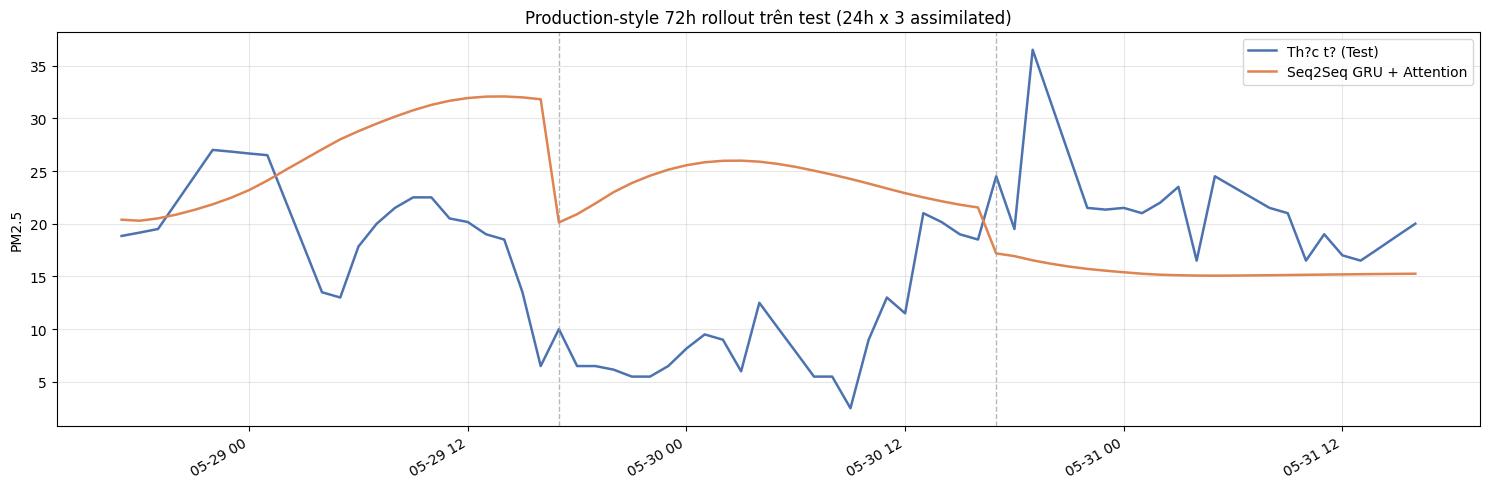

In [25]:
# ===== Walk-forward validate tren tap val, giu test hold-out =====

df_raw_rollout = df.copy().sort_index()
df_wf = build_history_feature_frame(df_raw_rollout).dropna().copy()

train_wf = df_wf[:train_end].copy()
val_wf = df_wf[val_start:val_end].copy()
test_wf = df_wf[test_start:].copy()

train_raw = df_raw_rollout[:train_end].copy()
val_raw = df_raw_rollout[val_start:val_end].copy()
test_raw = df_raw_rollout[test_start:].copy()

for feature_set_name in [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]:
    local_cols = candidate_feature_sets[feature_set_name]
    missing_feature_cols = [c for c in local_cols if c not in df_wf.columns]
    if missing_feature_cols:
        raise ValueError(f"Thi?u các c?t feature cho {feature_set_name}: {missing_feature_cols}")

MODEL_KWARGS = {
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
MODEL_LABEL = "Seq2Seq GRU + Attention" if MODEL_KWARGS.get("use_attention", False) else "Seq2Seq GRU"

def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, min_delta=1e-3),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ]


def split_train_inner_val(train_X_df, train_y_df, inner_val_size):
    min_train_rows = LOOKBACK + CHUNK_HORIZON
    if len(train_X_df) <= inner_val_size + min_train_rows:
        raise ValueError(
            f"Không d? d? li?u d? tách inner val. C?n > {inner_val_size + min_train_rows} rows, nh?n {len(train_X_df)}"
        )
    train_core_X = train_X_df.iloc[:-inner_val_size].copy()
    train_core_y = train_y_df.iloc[:-inner_val_size].copy()
    inner_val_X = train_X_df.iloc[-inner_val_size:].copy()
    inner_val_y = train_y_df.iloc[-inner_val_size:].copy()
    return train_core_X, train_core_y, inner_val_X, inner_val_y


def fit_selector_model(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không t?o du?c sequence cho train ho?c inner val. Ki?m tra l?i kích thu?c d? li?u và lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không t?o du?c sequence full-history")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_assimilated_rollout(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


val_feature_pool = val_wf[feature_cols].copy()
base_train_X = train_wf[feature_cols].copy()
base_train_y = train_wf[["PM25"]].copy()

fold_rows = []
compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model(
        train_core_X, train_core_y, inner_val_X, inner_val_y
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    fold_rows.append(fold_record)

walkforward_df = pd.DataFrame(fold_rows)
print("=== Walk-forward validation: production 72h rollout = 24h x 3 ===")
display(walkforward_df)

if not walkforward_df.empty:
    val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": walkforward_df["chunk_2_mae"].mean(),
            "mean_chunk_3_mae": walkforward_df["chunk_3_mae"].mean(),
        }
    ])
    print("\n=== Validation summary ===")
    display(val_summary_df)


# ===== Khoa config tren validation, train tren train+val va danh gia 1 lan tren test =====
train_val_feature_df = pd.concat([train_wf, val_wf], axis=0)
train_val_raw = pd.concat([train_raw, val_raw], axis=0)
test_rollout_raw = test_raw.iloc[:ROLLOUT_HORIZON].copy()

if len(test_rollout_raw) < ROLLOUT_HORIZON:
    raise ValueError("Không d? d? li?u test d? rollout d? 72h.")

test_variant = fit_test_variant(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_rollout_raw,
    model_kwargs=MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

best_epoch_test = test_variant["best_epoch"]
peak_threshold_test_train = test_variant["train_peak_threshold_t"]
peak_threshold_test_full = test_variant["train_full_peak_threshold_t"]
test_eval_summary = test_variant["rollout_summary"]
test_timeline_df = test_eval_summary["timeline_df"].copy()
test_chunk_metrics_df = test_eval_summary["chunk_metrics_df"].copy()
test_rollout_metrics = test_eval_summary["rollout_metrics"]

test_metrics_df = pd.DataFrame([
    {
        "best_epoch": best_epoch_test,
        "test_rollout_mae": test_rollout_metrics["mae"],
        "test_rollout_rmse": test_rollout_metrics["rmse"],
        "test_rollout_mape": test_rollout_metrics["mape"],
        "test_rollout_peak_mae": test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": peak_threshold_test_train,
        "train_val_peak_threshold_t": peak_threshold_test_full,
    }
])

test_report_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "rollout_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "MAPE": test_rollout_metrics["mape"],
        "best_epoch": best_epoch_test,
    }
])

print("\n=== Hold-out test rollout metrics ===")
display(test_metrics_df)
print("\n=== Chunk-level test metrics ===")
display(test_chunk_metrics_df)
print("\n=== Presentation table ===")
display(test_report_df)

plot_df = test_timeline_df.copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Th?c t? (Test)", linewidth=1.8, color="#4C72B0")
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")

for chunk_boundary in range(CHUNK_HORIZON, ROLLOUT_HORIZON, CHUNK_HORIZON):
    boundary_ts = plot_df.iloc[chunk_boundary]["timestamp"]
    plt.axvline(boundary_ts, color="#999999", linestyle="--", linewidth=1.0, alpha=0.7)

plt.title("Production-style 72h rollout trên test (24h x 3 assimilated)")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


In [26]:
# ===== Feature-set comparison: production vs optimistic =====

FEATURE_COMPARE_MODEL_LABEL = "Seq2Seq GRU + Attention"
FEATURE_COMPARE_MODEL_KWARGS = {**MODEL_KWARGS, "use_attention": True}
FEATURE_COMPARE_MAX_EPOCHS = min(EPOCHS, 30)


# Chạy cùng một kiến trúc model trên 2 bộ feature để thấy chênh lệch giữa production và optimistic.
def run_feature_set_variant(feature_set_name, model_label, model_kwargs):
    local_feature_cols = candidate_feature_sets[feature_set_name]
    local_variant = fit_test_variant(
        feature_cols_local=local_feature_cols,
        history_feature_df=train_val_feature_df,
        history_raw_df=train_val_raw,
        future_raw_df=test_rollout_raw,
        model_kwargs=model_kwargs,
        selector_epochs=FEATURE_COMPARE_MAX_EPOCHS,
    )
    rollout_summary = local_variant["rollout_summary"]
    rollout_metrics = rollout_summary["rollout_metrics"]

    return {
        "feature_set": feature_set_name,
        "label": model_label,
        "best_epoch": local_variant["best_epoch"],
        "n_features": len(local_feature_cols),
        "metrics": {
            "feature_set": feature_set_name,
            "n_features": len(local_feature_cols),
            "best_epoch": local_variant["best_epoch"],
            "test_rollout_mae": rollout_metrics["mae"],
            "test_rollout_rmse": rollout_metrics["rmse"],
            "test_rollout_mape": rollout_metrics["mape"],
            "test_rollout_peak_mae": rollout_metrics["peak_mae"],
        },
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
        "timeline_df": rollout_summary["timeline_df"].copy(),
    }


feature_compare_results = []
for feature_set_name in FEATURE_SET_COMPARE:
    print(f"Đang đánh giá feature set: {feature_set_name}")
    feature_compare_results.append(
        run_feature_set_variant(
            feature_set_name=feature_set_name,
            model_label=FEATURE_COMPARE_MODEL_LABEL,
            model_kwargs=FEATURE_COMPARE_MODEL_KWARGS,
        )
    )

feature_compare_df = pd.DataFrame([res["metrics"] for res in feature_compare_results])
feature_compare_df = feature_compare_df.sort_values(["test_rollout_mae", "test_rollout_rmse"]).reset_index(drop=True)
production_rollout_mae = float(
    feature_compare_df.loc[feature_compare_df["feature_set"] == SELECTED_FEATURE_SET, "test_rollout_mae"].iloc[0]
)
feature_compare_df["delta_vs_production_mae"] = feature_compare_df["test_rollout_mae"] - production_rollout_mae
print("=== So sánh feature set trên test rollout 72h ===")
display(feature_compare_df)

best_feature_set = feature_compare_df.loc[0, "feature_set"]
print("Feature set co MAE rollout tốt nhat:", best_feature_set)
if best_feature_set != SELECTED_FEATURE_SET:
    print("Lưu y: optimistic_v1 tốt hon trên test rollout cho thấy nguy cơ chenh lech giua bo feature nghien cuu va bo feature production.")


Đang đánh giá feature set: base_weather_pollution

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
Đang đánh giá feature set: optimistic_v1

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.
=== So sánh feature set trên test rollout 72h ===


,feature_set,n_features,best_epoch,test_rollout_mae,test_rollout_rmse,test_rollout_mape,test_rollout_peak_mae,delta_vs_production_mae
0,base_weather_pollution,33,14,9.485886,12.036579,107.499184,6.588711,0.000000
1,optimistic_v1,37,9,10.987780,12.637033,107.316379,9.202255,1.501894


Feature set co MAE rollout tốt nhat: base_weather_pollution


Đang train để so sánh cho: Seq2Seq GRU

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.


Tái sử dụng kết quả đã có cho: Seq2Seq GRU + Attention
=== Bảng so sánh ===


,model,mae,rmse,MAPE
0,Seq2Seq GRU,5.873686,7.280190,61.651610
1,Seq2Seq GRU + Attention,9.599333,11.529502,99.589503


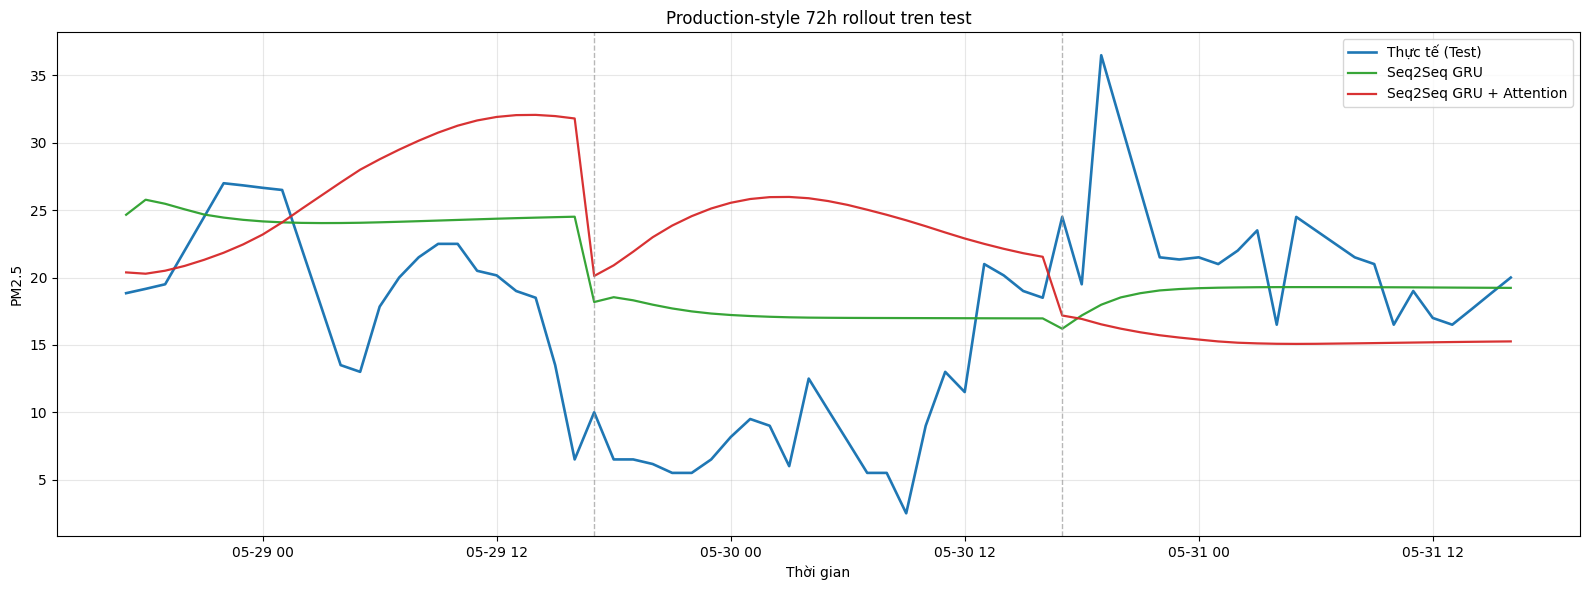

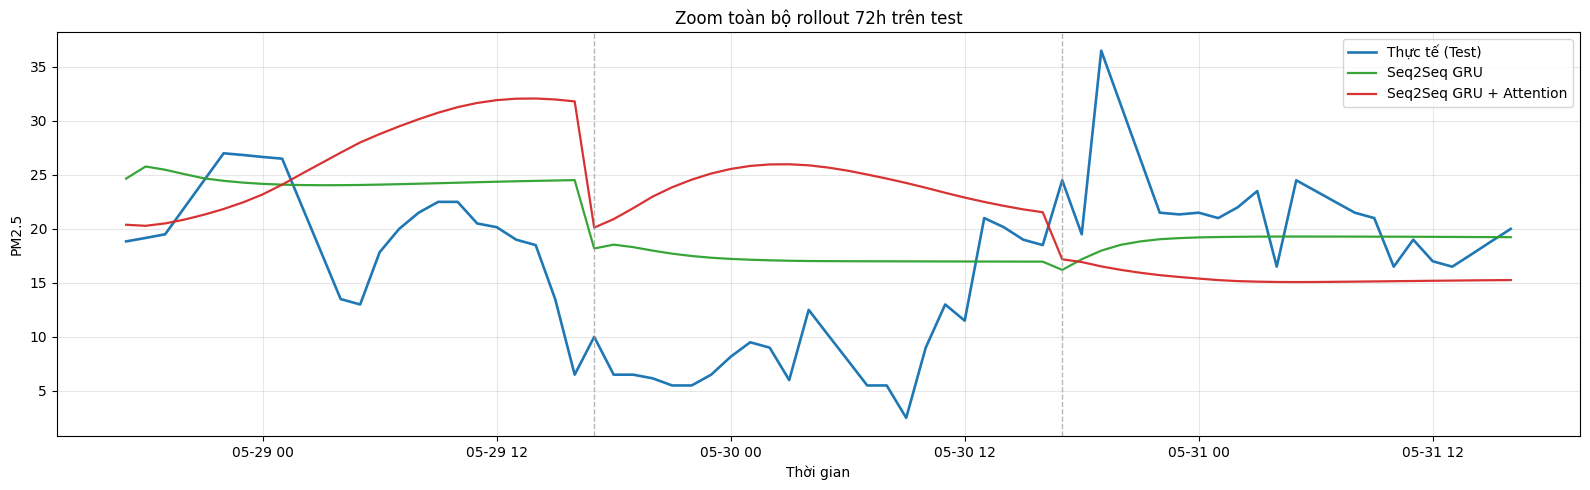

In [27]:
final_metrics_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "mape": test_rollout_metrics["mape"],
        "peak_mae": test_rollout_metrics["peak_mae"],
        "best_epoch": best_epoch_test,
    }
])

print("=== Ket qua final tren test ===")
display(final_metrics_df)

presentation_df = test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
presentation_df = presentation_df.rename(columns={"y_true": "actual", "y_pred": "prediction"})
presentation_df["timestamp"] = pd.to_datetime(presentation_df["timestamp"])
presentation_df[["actual", "prediction"]] = presentation_df[["actual", "prediction"]].round(2)

In [28]:
prediction_table = presentation_df.copy()
prediction_table["timestamp"] = pd.to_datetime(prediction_table["timestamp"])
prediction_table = prediction_table[["timestamp", "actual", "seq2seq_gru", "seq2seq_gru_attention"]].copy()
prediction_table[["actual", "seq2seq_gru", "seq2seq_gru_attention"]] = prediction_table[["actual", "seq2seq_gru", "seq2seq_gru_attention"]].round(2)

print(f"Tong so moc du lieu: {len(prediction_table)}")
print("\n20 dong dau tien:")
display(prediction_table.head(20))

print("\n20 dong cuoi cung:")
display(prediction_table.tail(20))

prediction_table

Tong so moc du lieu: 72

20 dong dau tien:


,timestamp,actual,seq2seq_gru,seq2seq_gru_attention
0,2025-05-28 17:00:00,18.84,24.66,20.38
1,2025-05-28 18:00:00,19.16,25.78,20.28
2,2025-05-28 19:00:00,19.50,25.47,20.51
3,2025-05-28 20:00:00,22.00,25.06,20.86
4,2025-05-28 21:00:00,24.50,24.68,21.32
5,2025-05-28 22:00:00,27.00,24.45,21.84
6,2025-05-28 23:00:00,26.84,24.28,22.46
7,2025-05-29 00:00:00,26.66,24.17,23.19
8,2025-05-29 01:00:00,26.50,24.10,24.09
9,2025-05-29 02:00:00,22.16,24.06,25.10



20 dong cuoi cung:


,timestamp,actual,seq2seq_gru,seq2seq_gru_attention
52,2025-05-30 21:00:00,26.50,18.84,15.94
53,2025-05-30 22:00:00,21.50,19.04,15.72
54,2025-05-30 23:00:00,21.34,19.15,15.55
55,2025-05-31 00:00:00,21.50,19.21,15.40
56,2025-05-31 01:00:00,21.00,19.25,15.26
57,2025-05-31 02:00:00,22.00,19.27,15.16
58,2025-05-31 03:00:00,23.50,19.28,15.11
59,2025-05-31 04:00:00,16.50,19.29,15.08
60,2025-05-31 05:00:00,24.50,19.29,15.07
61,2025-05-31 06:00:00,23.50,19.29,15.08


,timestamp,actual,seq2seq_gru,seq2seq_gru_attention
0,2025-05-28 17:00:00,18.84,24.66,20.38
1,2025-05-28 18:00:00,19.16,25.78,20.28
2,2025-05-28 19:00:00,19.50,25.47,20.51
3,2025-05-28 20:00:00,22.00,25.06,20.86
4,2025-05-28 21:00:00,24.50,24.68,21.32
...,...,...,...,...
67,2025-05-31 12:00:00,17.00,19.26,15.19
68,2025-05-31 13:00:00,16.50,19.25,15.21
69,2025-05-31 14:00:00,17.66,19.25,15.23
70,2025-05-31 15:00:00,18.84,19.24,15.25


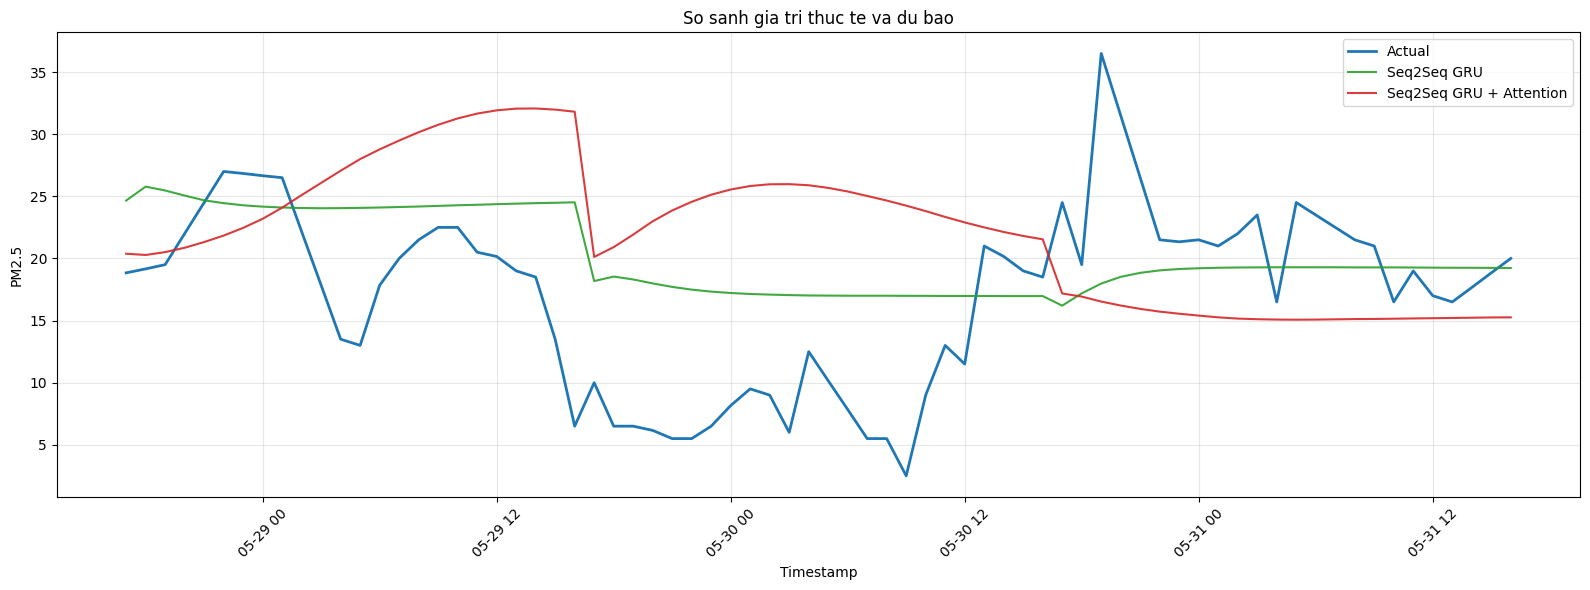

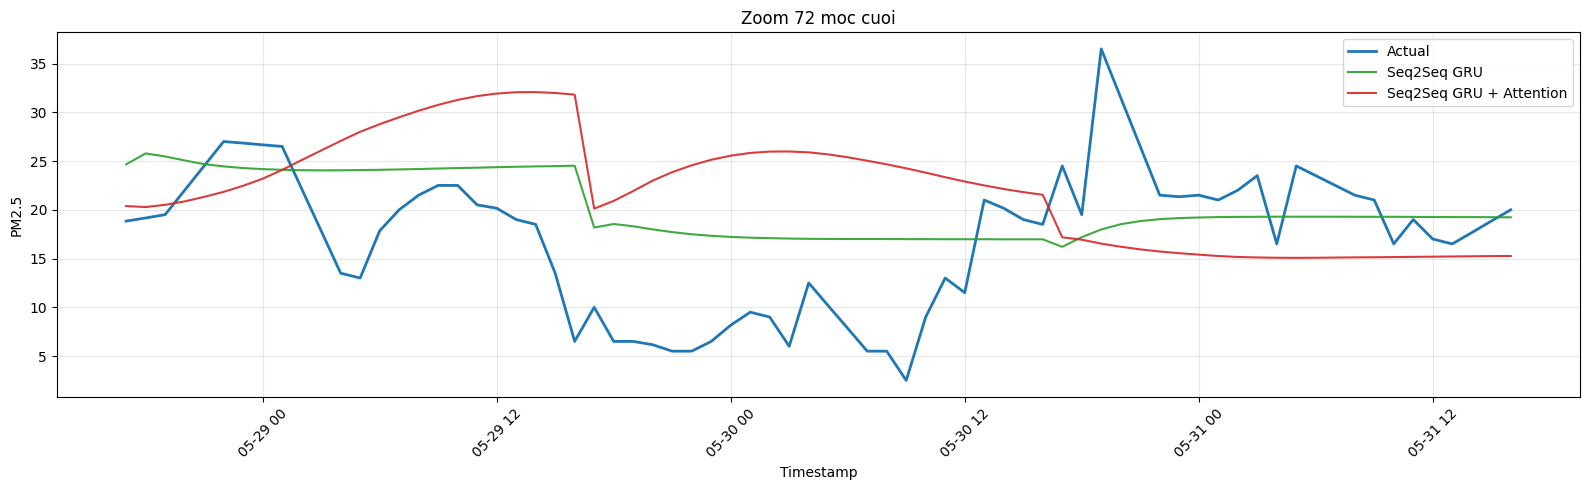

In [29]:
plt.figure(figsize=(16, 6))
plt.plot(prediction_table["timestamp"], prediction_table["actual"], label="Actual", linewidth=2.0, color="tab:blue")
plt.plot(prediction_table["timestamp"], prediction_table["seq2seq_gru"], label="Seq2Seq GRU", linewidth=1.5, alpha=0.9, color="tab:green")
plt.plot(prediction_table["timestamp"], prediction_table["seq2seq_gru_attention"], label="Seq2Seq GRU + Attention", linewidth=1.5, alpha=0.9, color="tab:red")
plt.title("So sanh gia tri thuc te va du bao")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zoom_n = min(200, len(prediction_table))
zoom_df = prediction_table.tail(zoom_n).copy()

plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Actual", linewidth=2.0, color="tab:blue")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru"], label="Seq2Seq GRU", linewidth=1.5, alpha=0.9, color="tab:green")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru_attention"], label="Seq2Seq GRU + Attention", linewidth=1.5, alpha=0.9, color="tab:red")
plt.title(f"Zoom {zoom_n} moc cuoi")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()